In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
X,y = make_moons(100, noise=0.25, random_state=2)

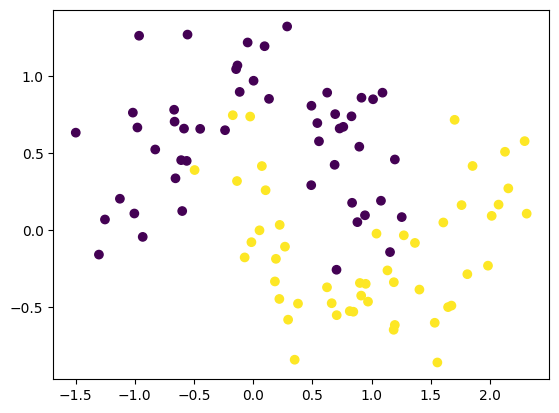

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [ ]:
model1 = Sequential()
model1.add(Dense(128, input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation="sigmoid"))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01)
model1.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

history1 = model1.fit(X,y.astype(int), epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


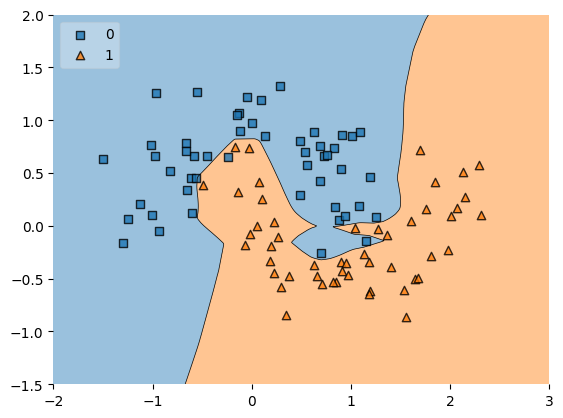

In [ ]:
plot_decision_regions(X, y.astype("int"), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

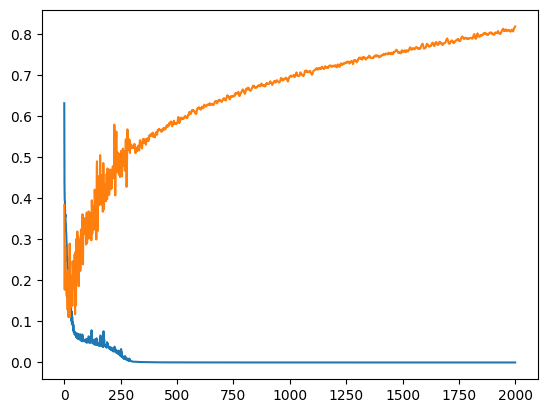

In [ ]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [ ]:
# L2-regularization
model2 = Sequential()
model2.add(Dense(128, input_dim=2, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.L2(0.05)))
model2.add(Dense(128, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.L2(0.03)))
model2.add(Dense(1, activation="sigmoid"))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01)
model2.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

history2 = model2.fit(X,y.astype(int), epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


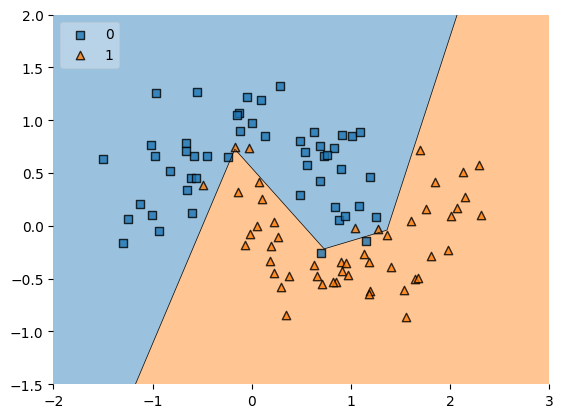

In [ ]:
plot_decision_regions(X, y.astype("int"), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

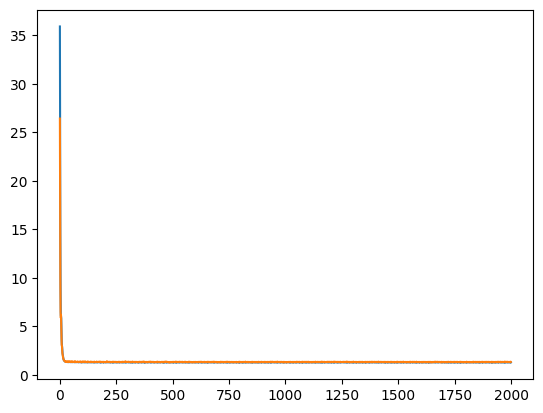

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [ ]:
# L1-regularization
model3 = Sequential()
model3.add(Dense(128, input_dim=2, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.L1(0.05)))
model3.add(Dense(128, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.L1(0.03)))
model3.add(Dense(1, activation="sigmoid"))

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01)
model3.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

history3 = model3.fit(X,y.astype(int), epochs=2000, validation_split=0.2, verbose=0)
history3

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


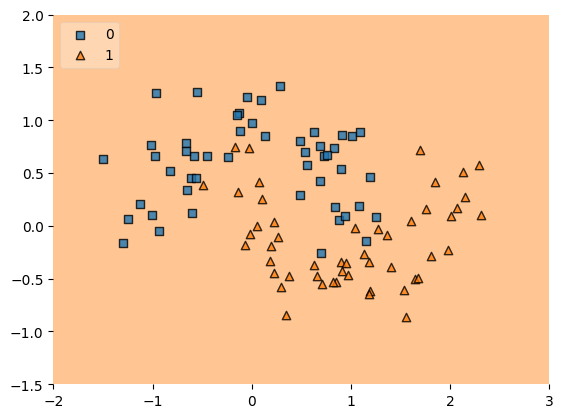

In [ ]:
plot_decision_regions(X, y.astype("int"), clf=model3, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

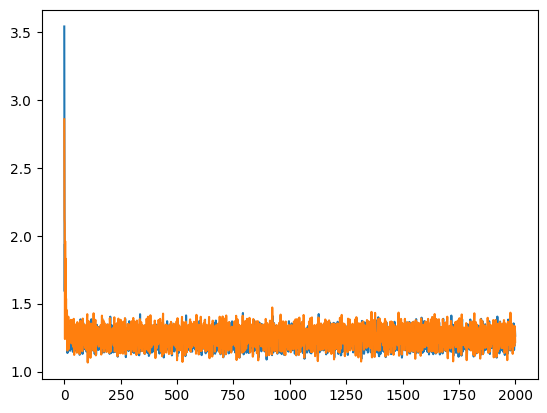

In [ ]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])

In [ ]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

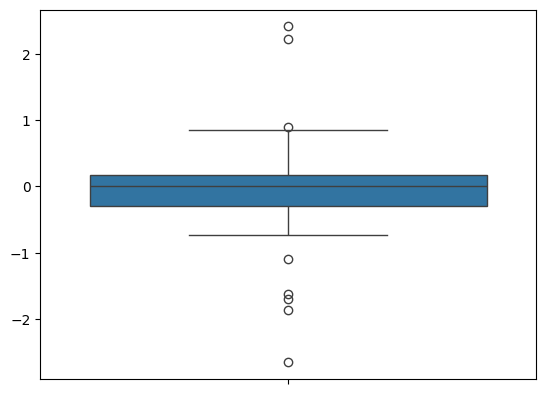

In [ ]:
sns.boxplot(model1_weight_layer1)

<Axes: >

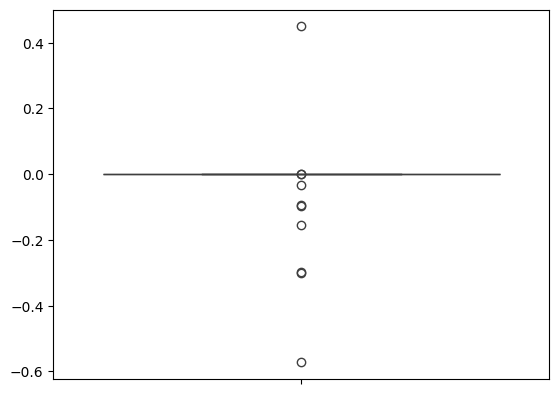

In [ ]:
sns.boxplot(model2_weight_layer1)

Weight decay

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
model_en = Sequential()
l_1 = 0.05
l_2 = 0.05
model_en.add(Dense(
    128,
    input_dim=2,
    activation="relu",
    kernel_regularizer=regularizers.L1L2(l1=l_1, l2=l_2)
))
model_en.add(Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.L1L2(l1=l_1, l2=l_2)
))
model_en.add(Dense(1, activation="sigmoid"))

model_en.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01)
model_en.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

history4 = model_en.fit(X,y.astype(int), epochs=2000, validation_split=0.2, verbose=0)
history4

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


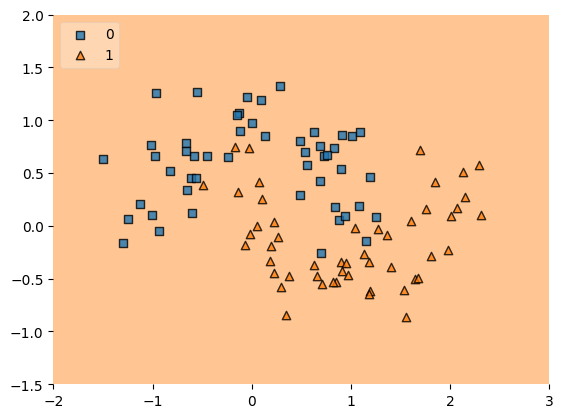

In [ ]:
plot_decision_regions(X, y.astype("int"), clf=model_en, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

In [ ]:
training_loss = history4.history["loss"]
validation_loss = history4.history["val_loss"]

training_acc = history4.history["accuracy"]
validation_acc = history4.history["val_accuracy"]

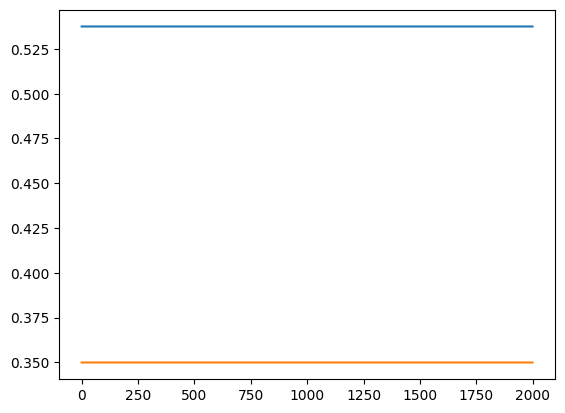

In [ ]:
plt.plot(training_acc)
plt.plot(validation_acc)

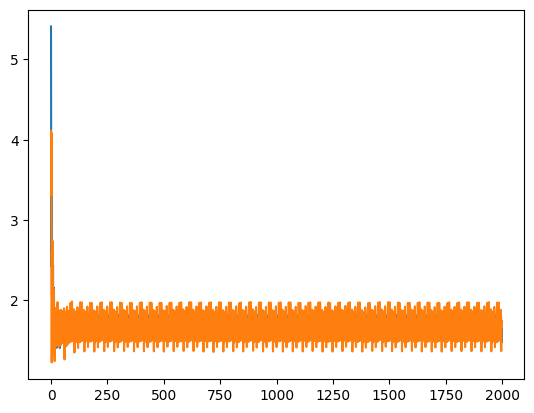

In [ ]:
plt.plot(training_loss)
plt.plot(validation_loss)

In [ ]:
# checking sparcity
import numpy as np

for layer in model_en.layers:
    weights = layer.get_weights()

    if len(weights) > 0:
        w = weights[0]
        zero_weights = np.sum(np.abs(w) < 0.01)
        total_weights = w.size

        sparsity = zero_weights / total_weights

        print("Layer sparsity:", sparsity)

Layer sparsity: 1.0
Layer sparsity: 1.0
Layer sparsity: 0.171875


Interpretation of Elastic Net Balance:

Elastic Net combines:

- L1 regularization → promotes sparsity
- L2 regularization → stabilizes weight magnitude

In this experiment:
- L1 penalty dominated
- resulting in high sparsity

causing model underfitting.

Input → dead layer → dead layer → output
- Which means the network is almost behaving like a constant classifier.
- This is similar to extreme underfitting.